# TT-10 — MLP Classifier: Đọc số viết tay trên séc / phiếu chuyển khoản


## 0. Cấu hình & thư viện

In [ ]:
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
import joblib


DATASET = "digits"     
QUICK = False          
RANDOM_STATE = 42
CONFIDENCE_THRESHOLD = 0.99   

REPORTS_DIR = Path("../reports")
MODELS_DIR = Path("../models")
REPORTS_DIR.mkdir(exist_ok=True, parents=True)
MODELS_DIR.mkdir(exist_ok=True, parents=True)

np.random.seed(RANDOM_STATE)
print(f"DATASET={DATASET} | QUICK={QUICK} | ngưỡng human-in-the-loop={CONFIDENCE_THRESHOLD}")

DATASET=digits | QUICK=False | ngưỡng human-in-the-loop=0.99


X=(1797, 64), y=(1797,), pixel range=[0.0,16.0], n_classes=10


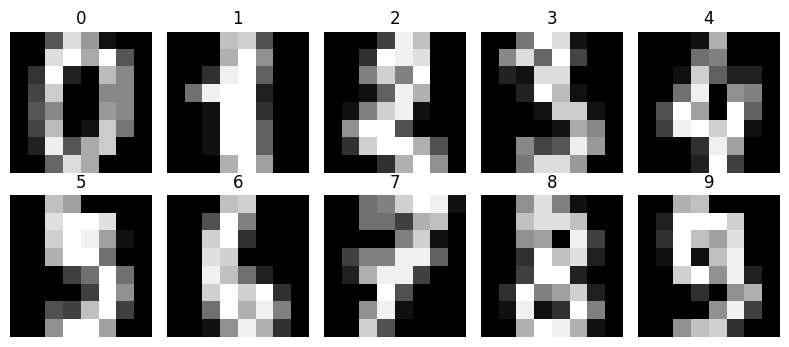

In [2]:
if DATASET == "digits":
    data = load_digits()
    X, y = data.data.astype(float), data.target.astype(int)
    img_shape = (8, 8)
elif DATASET == "mnist":
    print("Đang tải MNIST từ OpenML (lần đầu chậm, có cache cho lần sau)...")
    X, y = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)
    X = X.astype(float)
    y = y.astype(int)
    img_shape = (28, 28)
    if QUICK:
        idx = np.random.RandomState(RANDOM_STATE).choice(len(X), size=6000, replace=False)
        X, y = X[idx], y[idx]
else:
    raise ValueError("DATASET phải là 'digits' hoặc 'mnist'")

n_features = X.shape[1]
n_classes = len(np.unique(y))
print(f"X={X.shape}, y={y.shape}, pixel range=[{X.min()},{X.max()}], n_classes={n_classes}")

fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for i, ax in enumerate(axes.ravel()):
    ax.imshow(X[i].reshape(img_shape), cmap="gray")
    ax.set_title(int(y[i]))
    ax.axis("off")
plt.tight_layout()
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(len(X_train), "mẫu train,", len(X_test), "mẫu test")

1437 mẫu train, 360 mẫu test


## 3-4. Baseline Logistic Regression & so sánh CÓ / KHÔNG chuẩn hoá

In [ ]:
def make_mlp(hidden_layer_sizes=(128, 64), activation="relu",
             learning_rate_init=1e-3, max_iter=100):
    return MLPClassifier(
        hidden_layer_sizes=hidden_layer_sizes,
        activation=activation,
        solver="adam",
        alpha=1e-4,
        batch_size=128,
        learning_rate_init=learning_rate_init,
        max_iter=max_iter,
        early_stopping=True,      
        n_iter_no_change=10,
        random_state=RANDOM_STATE,
        verbose=False,
    )

def count_params(n_features, hidden_layer_sizes, n_classes):
    layers = [n_features, *hidden_layer_sizes, n_classes]
    return sum(a * b + b for a, b in zip(layers[:-1], layers[1:]))

In [5]:
results_normalization = {}

# Baseline: Logistic Regression (trên dữ liệu đã chuẩn hoá)
t0 = time.time()
logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train / 255.0, y_train)
acc_logreg = accuracy_score(y_test, logreg.predict(X_test / 255.0))
results_normalization["logistic_regression"] = {"accuracy": acc_logreg, "time_s": time.time() - t0}
print(f"[baseline] Logistic Regression accuracy = {acc_logreg:.4f}")

# MLP KHÔNG chuẩn hoá (pixel 0-255 nguyên gốc)
t0 = time.time()
mlp_raw = make_mlp(max_iter=50)
mlp_raw.fit(X_train, y_train)
acc_raw = accuracy_score(y_test, mlp_raw.predict(X_test))
results_normalization["mlp_khong_chuan_hoa"] = {"accuracy": acc_raw, "time_s": time.time() - t0, "n_iter": mlp_raw.n_iter_}
print(f"[KHÔNG chuẩn hoá] accuracy = {acc_raw:.4f} (n_iter={mlp_raw.n_iter_})")

# MLP CÓ chuẩn hoá /255  ← từ đây về sau luôn dùng bản đã chuẩn hoá
X_train_n, X_test_n = X_train / 255.0, X_test / 255.0
t0 = time.time()
mlp_norm = make_mlp()
mlp_norm.fit(X_train_n, y_train)
acc_norm = accuracy_score(y_test, mlp_norm.predict(X_test_n))
results_normalization["mlp_co_chuan_hoa"] = {"accuracy": acc_norm, "time_s": time.time() - t0, "n_iter": mlp_norm.n_iter_}
print(f"[CÓ chuẩn hoá]    accuracy = {acc_norm:.4f} (n_iter={mlp_norm.n_iter_})")

pd.DataFrame(results_normalization).T

[baseline] Logistic Regression accuracy = 0.8667
[KHÔNG chuẩn hoá] accuracy = 0.9667 (n_iter=29)
[CÓ chuẩn hoá]    accuracy = 0.9056 (n_iter=66)


,accuracy,time_s,n_iter
logistic_regression,0.866667,0.032598,NaN
mlp_khong_chuan_hoa,0.966667,0.652478,29.0
mlp_co_chuan_hoa,0.905556,1.611204,66.0


## 5-6. So sánh 4 kiến trúc (đếm tham số, accuracy, thời gian)

In [6]:
ARCHITECTURES = [(64,), (128,), (128, 64), (256, 128, 64)]

arch_rows = []
arch_models = {}
for arch in ARCHITECTURES:
    t0 = time.time()
    mlp = make_mlp(hidden_layer_sizes=arch)
    mlp.fit(X_train_n, y_train)
    acc = accuracy_score(y_test, mlp.predict(X_test_n))
    elapsed = time.time() - t0
    n_params = count_params(n_features, arch, n_classes)
    arch_rows.append({"architecture": str(arch), "n_params": n_params,
                       "accuracy": round(acc, 4), "train_time_s": round(elapsed, 2),
                       "n_iter": mlp.n_iter_})
    arch_models[str(arch)] = mlp
    print(f"[{arch}] acc={acc:.4f}, params={n_params}, time={elapsed:.1f}s, n_iter={mlp.n_iter_}")

df_arch = pd.DataFrame(arch_rows)
df_arch

[(64,)] acc=0.7694, params=4810, time=0.1s, n_iter=31
[(128,)] acc=0.8972, params=9610, time=1.4s, n_iter=100
[(128, 64)] acc=0.9056, params=17226, time=3.8s, n_iter=66
[(256, 128, 64)] acc=0.9639, params=58442, time=4.0s, n_iter=78


,architecture,n_params,accuracy,train_time_s,n_iter
0,"(64,)",4810,0.7694,0.13,31
1,"(128,)",9610,0.8972,1.41,100
2,"(128, 64)",17226,0.9056,3.75,66
3,"(256, 128, 64)",58442,0.9639,4.02,78


## 7. Loss curve theo kiến trúc

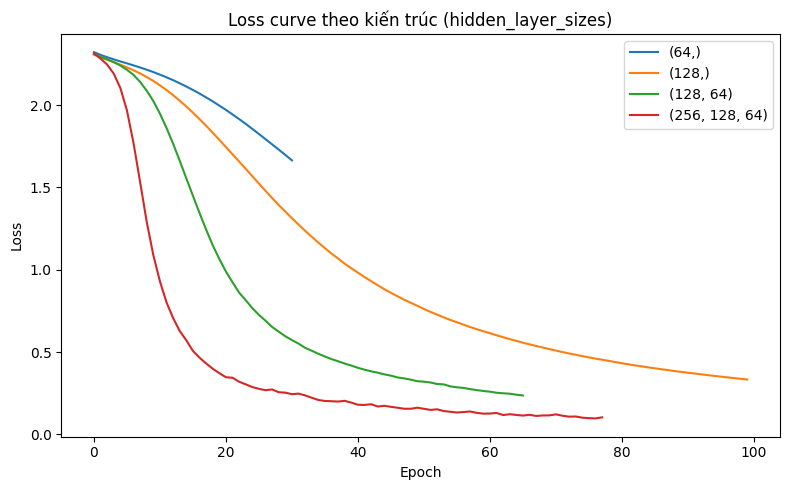

Đã lưu model chính -> ..\models\mlp_pipeline.joblib


In [7]:
plt.figure(figsize=(8, 5))
for name, model in arch_models.items():
    plt.plot(model.loss_curve_, label=name)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss curve theo kiến trúc (hidden_layer_sizes)")
plt.legend(); plt.tight_layout()
plt.savefig(REPORTS_DIR / "loss_curves.png")
plt.show()

# Model chính dùng để đánh giá các bước tiếp theo = kiến trúc (128, 64) như đề bài
best_model = arch_models["(128, 64)"]
joblib.dump(best_model, MODELS_DIR / "mlp_pipeline.joblib")
print("Đã lưu model chính ->", MODELS_DIR / "mlp_pipeline.joblib")

## 8. So sánh activation: relu / tanh / logistic
(gợi ý: `logistic` gây vanishing gradient → học rất chậm)

[relu] acc=0.9056, n_iter=66
[tanh] acc=0.9444, n_iter=59
[logistic] acc=0.1000, n_iter=14


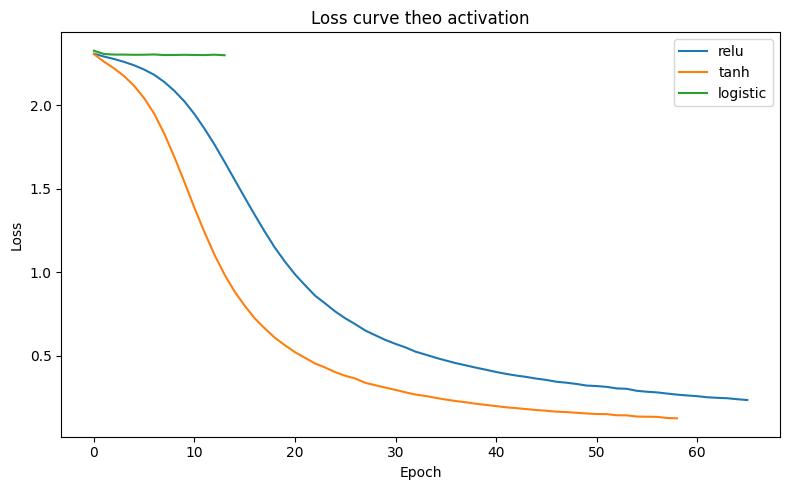

,activation,accuracy,n_iter,train_time_s
0,relu,0.9056,66,1.35
1,tanh,0.9444,59,1.15
2,logistic,0.1000,14,0.56


In [8]:
act_rows = []
act_curves = {}
for act in ["relu", "tanh", "logistic"]:
    t0 = time.time()
    mlp = make_mlp(activation=act)
    mlp.fit(X_train_n, y_train)
    acc = accuracy_score(y_test, mlp.predict(X_test_n))
    act_rows.append({"activation": act, "accuracy": round(acc, 4),
                      "n_iter": mlp.n_iter_, "train_time_s": round(time.time() - t0, 2)})
    act_curves[act] = mlp.loss_curve_
    print(f"[{act}] acc={acc:.4f}, n_iter={mlp.n_iter_}")

plt.figure(figsize=(8, 5))
for act, curve in act_curves.items():
    plt.plot(curve, label=act)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss curve theo activation")
plt.legend(); plt.tight_layout()
plt.savefig(REPORTS_DIR / "activation_comparison.png")
plt.show()

pd.DataFrame(act_rows)

## 9. So sánh learning_rate_init: 1e-2 / 1e-3 / 1e-4

[lr=0.01] acc=0.9639, n_iter=43
[lr=0.001] acc=0.9056, n_iter=66
[lr=0.0001] acc=0.0972, n_iter=12


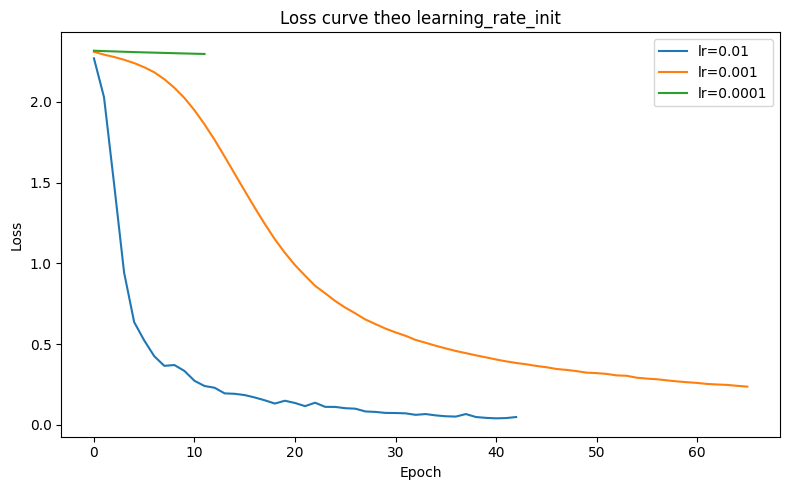

,learning_rate,accuracy,n_iter
0,0.0100,0.9639,43
1,0.0010,0.9056,66
2,0.0001,0.0972,12


In [9]:
lr_rows = []
plt.figure(figsize=(8, 5))
for lr in [1e-2, 1e-3, 1e-4]:
    mlp = make_mlp(learning_rate_init=lr)
    mlp.fit(X_train_n, y_train)
    acc = accuracy_score(y_test, mlp.predict(X_test_n))
    lr_rows.append({"learning_rate": lr, "accuracy": round(acc, 4), "n_iter": mlp.n_iter_})
    plt.plot(mlp.loss_curve_, label=f"lr={lr}")
    print(f"[lr={lr}] acc={acc:.4f}, n_iter={mlp.n_iter_}")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Loss curve theo learning_rate_init")
plt.legend(); plt.tight_layout()
plt.savefig(REPORTS_DIR / "learning_rate_curves.png")
plt.show()

pd.DataFrame(lr_rows)

## 10. Ma trận nhầm lẫn 10x10

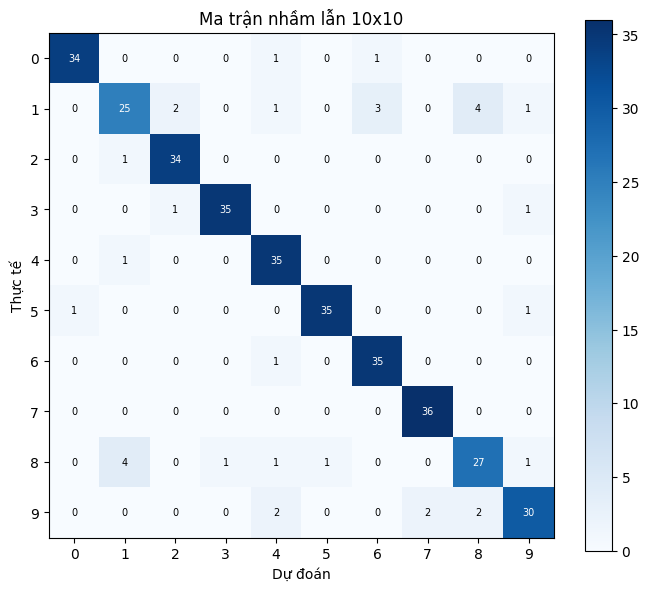

Top cặp nhầm lẫn: [{'that': 8, 'du_doan': 1, 'so_luong': 4}, {'that': 1, 'du_doan': 8, 'so_luong': 4}, {'that': 1, 'du_doan': 6, 'so_luong': 3}, {'that': 9, 'du_doan': 8, 'so_luong': 2}, {'that': 9, 'du_doan': 4, 'so_luong': 2}]


In [10]:
y_pred = best_model.predict(X_test_n)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(cm.shape[0])); ax.set_yticks(range(cm.shape[0]))
ax.set_xlabel("Dự đoán"); ax.set_ylabel("Thực tế")
ax.set_title("Ma trận nhầm lẫn 10x10")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=7)
fig.colorbar(im); fig.tight_layout()
fig.savefig(REPORTS_DIR / "confusion_10x10.png")
plt.show()

# Cặp số hay nhầm nhất (bỏ đường chéo)
cm_off = cm.copy()
np.fill_diagonal(cm_off, 0)
flat_idx = np.argsort(cm_off, axis=None)[::-1][:5]
top_confusions = []
for idx in flat_idx:
    i, j = np.unravel_index(idx, cm_off.shape)
    if cm_off[i, j] > 0:
        top_confusions.append({"that": int(i), "du_doan": int(j), "so_luong": int(cm_off[i, j])})
print("Top cặp nhầm lẫn:", top_confusions)

## 11. Xem 20 ảnh bị dự đoán sai

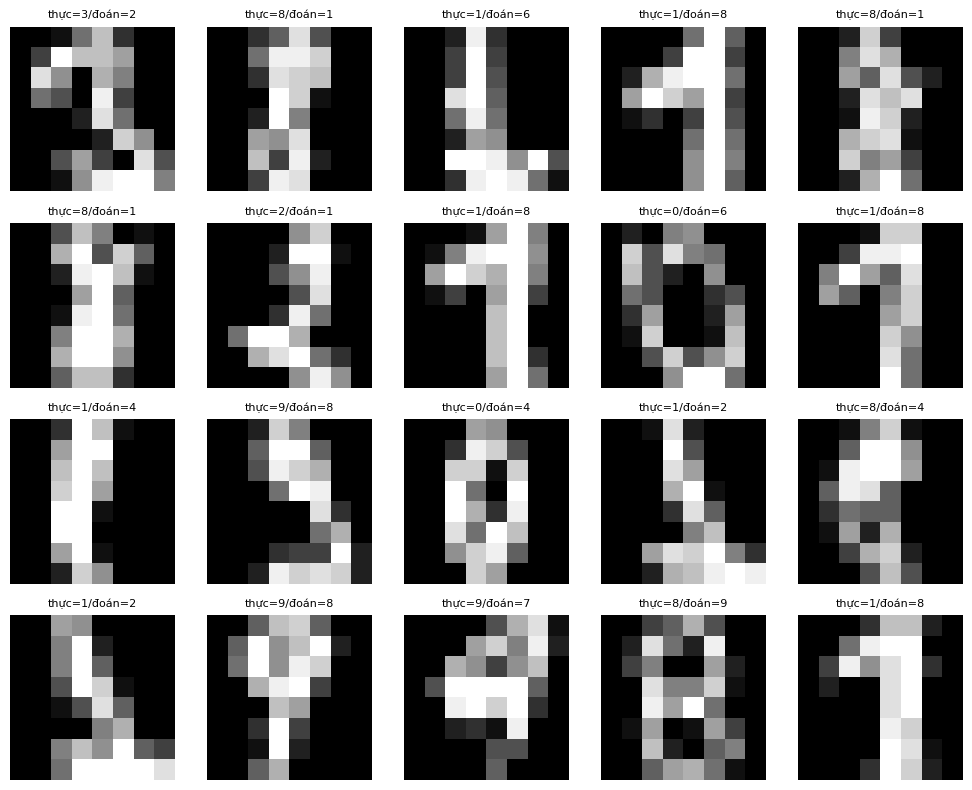

In [11]:
wrong_idx = np.where(y_pred != y_test)[0]
n_show = min(20, len(wrong_idx))

if n_show == 0:
    print("Không có ảnh dự đoán sai nào!")
else:
    chosen = np.random.RandomState(RANDOM_STATE).choice(wrong_idx, size=n_show, replace=False)
    cols = 5
    rows_ = int(np.ceil(n_show / cols))
    fig, axes = plt.subplots(rows_, cols, figsize=(cols * 2, rows_ * 2))
    axes = np.array(axes).reshape(-1)
    for ax_i, idx in enumerate(chosen):
        axes[ax_i].imshow(X_test[idx].reshape(img_shape), cmap="gray")
        axes[ax_i].set_title(f"thực={y_test[idx]}/đoán={y_pred[idx]}", fontsize=8)
        axes[ax_i].axis("off")
    for ax_i in range(len(chosen), len(axes)):
        axes[ax_i].axis("off")
    fig.tight_layout()
    fig.savefig(REPORTS_DIR / "anh_sai.png")
    plt.show()

## 12. Human-in-the-loop — ngưỡng độ tin cậy 99%

Sai 1 chữ số trong số tiền séc = sai tiền thật → chỉ tự động xử lý khi model
đủ tự tin (`predict_proba` ≥ ngưỡng), phần còn lại chuyển cho người kiểm tra.

In [12]:
proba = best_model.predict_proba(X_test_n)
confidence = proba.max(axis=1)
y_pred_hitl = proba.argmax(axis=1)

auto_mask = confidence >= CONFIDENCE_THRESHOLD
n_auto, n_manual = auto_mask.sum(), (~auto_mask).sum()
pct_auto = n_auto / len(y_test) * 100
pct_manual = n_manual / len(y_test) * 100
acc_auto = accuracy_score(y_test[auto_mask], y_pred_hitl[auto_mask]) if n_auto > 0 else float("nan")
acc_overall = accuracy_score(y_test, y_pred_hitl)

human_in_the_loop = {
    "threshold": CONFIDENCE_THRESHOLD,
    "pct_tu_dong": round(pct_auto, 2),
    "pct_chuyen_nguoi": round(pct_manual, 2),
    "accuracy_tren_phan_tu_dong": round(acc_auto, 4) if n_auto > 0 else None,
    "accuracy_tong_the_khong_loc": round(acc_overall, 4),
}
print(f"Ngưỡng {CONFIDENCE_THRESHOLD*100:.0f}%: {pct_auto:.1f}% séc tự động xử lý "
      f"(accuracy={acc_auto:.4f}), {pct_manual:.1f}% cần người kiểm tra")
human_in_the_loop

Ngưỡng 99%: 9.7% séc tự động xử lý (accuracy=1.0000), 90.3% cần người kiểm tra


{'threshold': 0.99,
 'pct_tu_dong': np.float64(9.72),
 'pct_chuyen_nguoi': np.float64(90.28),
 'accuracy_tren_phan_tu_dong': 1.0,
 'accuracy_tong_the_khong_loc': 0.9056}

## Tổng hợp kết quả & lưu file

In [13]:
final_accuracy = accuracy_score(y_test, best_model.predict(X_test_n))
print(f"Accuracy cuối cùng — model (128, 64): {final_accuracy:.4f}")

all_results = {
    "dataset": DATASET,
    "n_train": len(X_train), "n_test": len(X_test),
    "baseline_va_chuan_hoa": results_normalization,
    "so_sanh_kien_truc": arch_rows,
    "so_sanh_activation": act_rows,
    "so_sanh_learning_rate": lr_rows,
    "top_cap_nham_lan": top_confusions,
    "human_in_the_loop_99": human_in_the_loop,
    "final_accuracy_128_64": round(final_accuracy, 4),
}
with open(REPORTS_DIR / "results_summary.json", "w", encoding="utf-8") as f:
    json.dump(all_results, f, ensure_ascii=False, indent=2)
print("Đã lưu ->", REPORTS_DIR / "results_summary.json")

Accuracy cuối cùng — model (128, 64): 0.9056
Đã lưu -> ..\reports\results_summary.json


## 13. So sánh với CNN (TT-26) & kết luận

- MLP xử lý ảnh dưới dạng vector 1 chiều (flatten) → **mất cấu trúc không
  gian** của ảnh, không có tính bất biến dịch chuyển (translation
  invariance) như CNN.
- Mức tham chiếu: MLP đạt ~0,97–0,98 trên MNIST; CNN (TT-26) đạt > 0,99.
- Nếu `DATASET = "digits"` (chạy nhanh để test pipeline), accuracy sẽ **thấp
  hơn hẳn** vì `load_digits()` chỉ có 1.797 ảnh nhỏ 8x8 — đây là bình thường,
  không phải lỗi. Chuyển `DATASET = "mnist"` và chạy lại (Run All) để có kết
  quả chính thức đạt chuẩn accuracy ≥ 0,96 theo tiêu chí đề bài.